# Single Case Attribution Analysis

This notebook provides detailed attribution analysis for a single case:

1. **Input**: Case name/ID + prefix length + attribution target
2. **Output**: Full attribution matrix for every suffix prediction step
3. **Visualization**: Interactive navigation through suffix steps

Use this notebook to understand how the model makes predictions for individual cases.

## 1. Setup

In [1]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

# Add both project root and src/ to path (src/ needed for pickle compatibility)
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.helpdesk_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: Helpdesk


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

## 2. Select Case for Analysis

In [4]:
# List available cases
case_names = list(eval_helper.cases.keys())
print(f"Sample cases: {case_names[:10]}")
print(f"Total cases: {len(case_names)}")

Sample cases: ['Case 1016', 'Case 102', 'Case 1032', 'Case 1034', 'Case 1039', 'Case 1040', 'Case 105', 'Case 1058', 'Case 1061', 'Case 1066']
Total cases: 916


In [5]:
# ============================================================
# CONFIGURATION - Set your case and prefix length here
# ============================================================
CASE_NAME = "Case 2928" # Change this to analyze a specific case
PREFIX_LENGTH = 1          # Change this to set prefix length
TARGET = CONFIG.concept_name  # Usually 'Activity'

print(f"Analyzing: {CASE_NAME}, prefix_len={PREFIX_LENGTH}, target={TARGET}")

Analyzing: Case 2928, prefix_len=1, target=Activity


In [6]:
# Get case data
def get_case_data(case_name, prefix_len, eval_helper):
    """Get prefix and suffix data for a case."""
    if case_name not in eval_helper.cases:
        raise ValueError(f"Case {case_name} not found")
    
    full_case = eval_helper.cases[case_name]
    
    for pl, prefix, suffix in eval_helper._iterate_case(full_case):
        if pl == prefix_len:
            return prefix, suffix
    
    raise ValueError(f"Prefix length {prefix_len} not found for case {case_name}")

prefix, suffix = get_case_data(CASE_NAME, PREFIX_LENGTH, eval_helper)
print(f"Got prefix with {PREFIX_LENGTH} events")

Got prefix with 1 events


## 3. Compute Attribution for Each Suffix Step

In [7]:
def compute_suffix_step_attributions(tool, prefix, prefix_len, target, n_steps=50, max_suffix_steps=10):
    """
    Compute attribution maps for each step of suffix prediction.
    
    Returns:
        List of (suffix_step, attribution_map, predicted_activity) tuples
    """
    # Convert prefix format
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    results = []
    
    for suffix_step in range(max_suffix_steps):
        try:
            attr_map = tool.compute_attribution_map(
                process=process,
                prefix_length=prefix_len,
                target=target,
                target_class='auto',  # Use predicted class
                suffix_scope='step',
                suffix_step=suffix_step,
                method='integrated_gradients',
                n_steps=n_steps
            )
            
            # Check if EOS was predicted (end of suffix)
            if 'EOS' in attr_map.target_description or 'END' in attr_map.target_description:
                results.append((suffix_step, attr_map, 'EOS'))
                break
            
            results.append((suffix_step, attr_map, attr_map.target_description))
            
        except Exception as e:
            print(f"Stopped at suffix step {suffix_step}: {e}")
            break
    
    return results

print("Computing attributions for each suffix step...")
suffix_attributions = compute_suffix_step_attributions(
    tool, prefix, PREFIX_LENGTH, TARGET, 
    n_steps=CONFIG.ig_steps,
    max_suffix_steps=10
)
print(f"Computed attributions for {len(suffix_attributions)} suffix steps")

Computing attributions for each suffix step...
Computed attributions for 4 suffix steps


## 4. Visualize Attribution Matrix per Suffix Step

In [8]:
def plot_attribution_heatmap(attr_map, title_prefix="", figsize=(14, 8)):
    """
    Plot attribution matrix as a heatmap.
    """
    # Build matrix from attributions
    matrix = attr_map.to_numpy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Disable grid (can cause artifacts with heatmaps)
    ax.grid(False)
    
    # Use diverging colormap centered at 0
    vmax = np.abs(matrix).max()
    if vmax == 0:
        vmax = 1
    
    # Use interpolation='nearest' to prevent artifacts between cells
    im = ax.imshow(matrix, cmap='RdBu_r', aspect='auto', 
                   vmin=-vmax, vmax=vmax, interpolation='nearest')
    
    # Labels
    ax.set_yticks(range(len(attr_map.feature_names)))
    ax.set_yticklabels(attr_map.feature_names)
    ax.set_xticks(range(len(attr_map.step_labels)))
    ax.set_xticklabels(attr_map.step_labels, rotation=45, ha='right')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Attribution Score')
    
    ax.set_xlabel('Prefix Events')
    ax.set_ylabel('Features')
    ax.set_title(f"{title_prefix}{attr_map.target_description}")
    
    # Add value annotations for smaller matrices
    if matrix.shape[0] * matrix.shape[1] <= 50:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                color = 'white' if abs(val) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                       color=color, fontsize=11)
    
    plt.tight_layout()
    return fig

In [9]:
# Display attribution for each suffix step
for suffix_step, attr_map, pred in suffix_attributions:
    print(f"\n{'='*80}")
    print(f"SUFFIX STEP {suffix_step}: {pred}")
        
    # Also print text version
    print(attr_map.to_string())


SUFFIX STEP 0: Activity = Take in charge ticket (class 13) [integrated_gradients]
ATTRIBUTION MAP: Activity = Take in charge ticket (class 13) [integrated_gradients]
Prefix length: 1 | Suffix scope: step
Convergence delta: 0.000576

                      enc(Insert..    dec(SOS)
----------------------------------------------
            Activity |      0.1244      0.2628
            Resource |      0.0658      0.1733
       Variant index |      0.1920      0.0000
         seriousness |      0.0101      0.0000
            customer |      0.0516      0.0000
             product |      0.0379      0.0000
 responsible_section |      0.0816      0.0000
       seriousness_2 |      0.0160      0.0000
       service_level |      0.0435      0.0000
        service_type |      0.0439      0.0000
     support_section |      0.0204      0.0000
           workgroup |      0.0069      0.0000
   case_elapsed_time |      0.0530      0.1605
  event_elapsed_time |      0.0000      0.0000
         day_i

## 5. Interactive Suffix Step Navigator

In [10]:
# Interactive widget to navigate through suffix steps
if len(suffix_attributions) > 0:
    @interact(step=widgets.IntSlider(min=0, max=len(suffix_attributions)-1, value=0, description='Suffix Step'))
    def show_step(step):
        suffix_step, attr_map, pred = suffix_attributions[step]
        
        print(f"Suffix Step {suffix_step}: Predicting {pred}")
        print(f"Convergence delta: {attr_map.convergence_delta:.6f}" if attr_map.convergence_delta else "")
        
        fig = plot_attribution_heatmap(attr_map, f"Step {suffix_step}: ")
        plt.show()
else:
    print("No suffix attributions computed.")

interactive(children=(IntSlider(value=0, description='Suffix Step', max=3), Output()), _dom_classes=('widget-i…

## 6. Feature Importance Across Suffix Steps

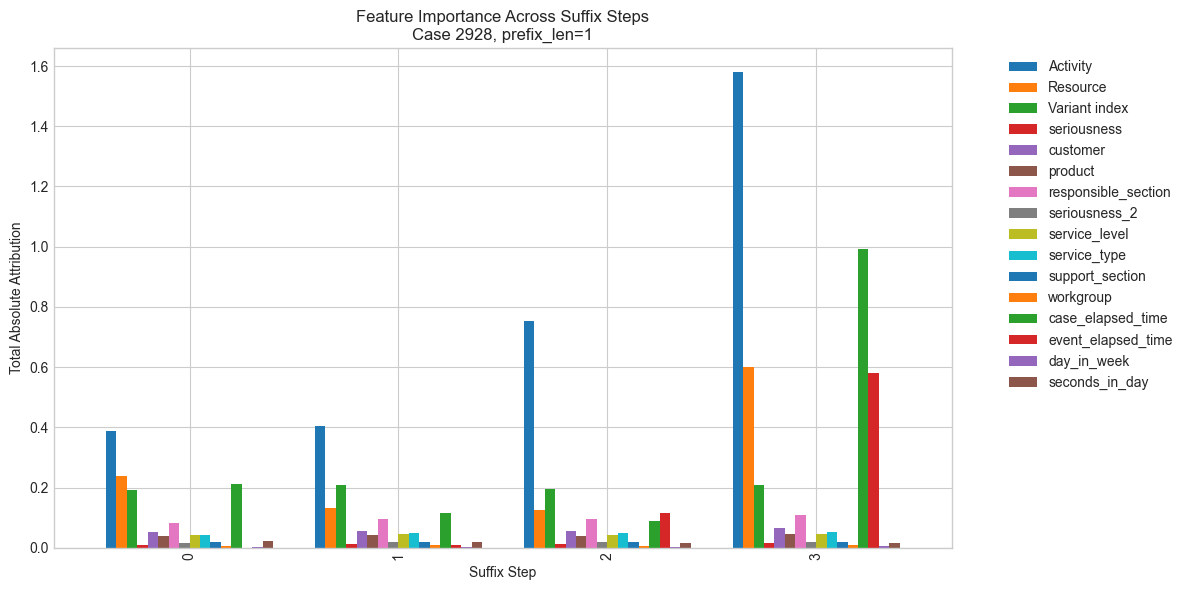


Feature importance by suffix step:


,Activity,Resource,Variant index,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
Suffix Step,,,,,,,,,,,,,,,,
0,0.387249,0.239115,0.192031,0.010052,0.051568,0.037880,0.081559,0.015999,0.043485,0.043852,0.020385,0.006942,0.213512,4.845834e-09,0.001728,0.021640
1,0.406219,0.133207,0.209273,0.013100,0.056647,0.041231,0.096774,0.020394,0.047409,0.049664,0.020808,0.007768,0.116319,9.949531e-03,0.003381,0.020075
2,0.752945,0.125378,0.195458,0.013215,0.055600,0.040757,0.095358,0.019774,0.043552,0.048037,0.018954,0.007254,0.087802,1.172874e-01,0.003799,0.016534
3,1.581466,0.600873,0.209538,0.014669,0.064961,0.045943,0.107769,0.020862,0.046108,0.052335,0.019972,0.008373,0.992203,5.808746e-01,0.004938,0.015969


In [11]:
# Aggregate feature importance across all suffix steps
if suffix_attributions:
    feature_importance_by_step = {}
    
    for suffix_step, attr_map, pred in suffix_attributions:
        feature_importance_by_step[suffix_step] = {}
        
        for feat in attr_map.feature_names:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                feature_importance_by_step[suffix_step][feat] = np.abs(vals).sum()
    
    # Create DataFrame
    importance_df = pd.DataFrame(feature_importance_by_step).T
    importance_df.index.name = 'Suffix Step'
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    importance_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Suffix Step')
    ax.set_ylabel('Total Absolute Attribution')
    ax.set_title(f'Feature Importance Across Suffix Steps\n{CASE_NAME}, prefix_len={PREFIX_LENGTH}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    print("\nFeature importance by suffix step:")
    display(importance_df)

## 7. Encoder vs Decoder Split

Encoder vs Decoder Attribution Split:
  Encoder: 91.5% (total: 11.3600)
  Decoder SOS: 8.5% (total: 1.0573)


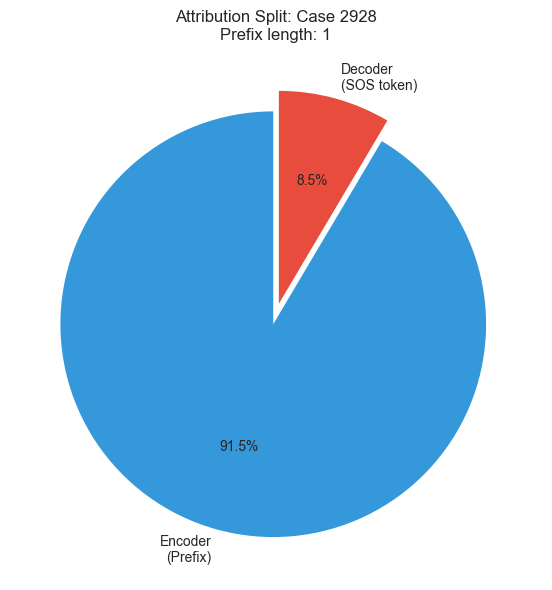

In [12]:
# Compute encoder vs decoder split for first suffix step
if suffix_attributions:
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    actual_len, prefix_for_split = tool.extract_prefix_from_process(process, PREFIX_LENGTH)
    
    split = tool.compute_encoder_decoder_attribution_split(
        prefix=prefix_for_split,
        target_output=TARGET,
        target_value='auto',
        suffix_step=0,
        n_steps=CONFIG.ig_steps
    )
    
    print(f"Encoder vs Decoder Attribution Split:")
    print(f"  Encoder: {split['encoder_fraction']*100:.1f}% (total: {split['encoder_total']:.4f})")
    print(f"  Decoder SOS: {split['decoder_sos_fraction']*100:.1f}% (total: {split['decoder_sos_total']:.4f})")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(8, 6))
    labels = ['Encoder\n(Prefix)', 'Decoder\n(SOS token)']
    sizes = [split['encoder_fraction'], split['decoder_sos_fraction']]
    colors = ['#3498db', '#e74c3c']
    
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
           startangle=90, explode=(0.05, 0.05))
    ax.set_title(f'Attribution Split: {CASE_NAME}\nPrefix length: {PREFIX_LENGTH}')
    plt.tight_layout()
    plt.show()

## 8. Summary

In [13]:
print("="*80)
print(f"SUMMARY: Single Case Attribution Analysis")
print("="*80)
print(f"\nCase: {CASE_NAME}")
print(f"Prefix length: {PREFIX_LENGTH}")
print(f"Target: {TARGET}")
print(f"\nSuffix predictions:")
for step, attr_map, pred in suffix_attributions:
    print(f"  Step {step}: {pred}")

if suffix_attributions:
    print(f"\nTop features (first suffix step):")
    first_attr = suffix_attributions[0][1]
    feature_totals = {}
    for feat in first_attr.feature_names:
        if feat in first_attr.attributions:
            vals = first_attr.attributions[feat]
            if hasattr(vals, 'detach'):
                vals = vals.detach().cpu().numpy()
            feature_totals[feat] = np.abs(vals).sum()
    
    for feat, val in sorted(feature_totals.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {feat}: {val:.4f}")

SUMMARY: Single Case Attribution Analysis

Case: Case 2928
Prefix length: 1
Target: Activity

Suffix predictions:
  Step 0: Activity = Take in charge ticket (class 13) [integrated_gradients]
  Step 1: Activity = Resolve ticket (class 11) [integrated_gradients]
  Step 2: Activity = Closed (class 2) [integrated_gradients]
  Step 3: EOS

Top features (first suffix step):
  Activity: 0.3872
  Resource: 0.2391
  case_elapsed_time: 0.2135
  Variant index: 0.1920
  responsible_section: 0.0816
